<img src="https://datasciencedegree.wisconsin.edu/wp-content/themes/data-gulp/images/logo.svg" width="300">

 # <center>DS 710 - Lesson 6c</center>

This is the third of three notebooks for Lesson 6, on pandas.  If you have not yet completed Lesson 6a and 6b, please return here once you have.

This training notebook focuses on some of the nifty parts of the `pandas` data framing library, such as `apply`, ways to filter, and some reductions and transformations. We touched on these in Lesson 6a but will really dive into them here.

References for this notebook include (but are not limited to) 
* Chapters 5-8 and Chapter 10 in your textbook (the author of the book is also one of the authors of Pandas, and it shows!), 
* Official Pandas Documentation including the [User Guide](https://pandas.pydata.org/docs/user_guide/index.html), and the [API Reference](https://pandas.pydata.org/docs/reference/index.html#api).

In [1]:
# as usual, importing as pd to keep code shorter.  pd is canonical.
import pandas as pd
import numpy as np

---

## 1.1 Apply

The pattern of `apply` is fairly broad, and doesn't just apply to data frames (pun intended).  You can also apply to lists and other iterables via `map`.  See [here](https://www.kite.com/python/answers/how-to-apply-a-function-to-a-list-in-python).  In this notebook, we'll be using `apply` in Pandas.  

The version of `apply` in pandas works to pass data in a data frame, series, or other data structure through a given function.  


In [2]:
ice_cream = pd.DataFrame(np.random.randint(0,12,size=(4,3)), columns=['cup','bowl','bucket'], index=['Chocolate', 'Vanilla', 'Strawberry', 'Pistachio']) 
# similar to an example in our book, in subsection "Function application and mapping"

In [3]:
ice_cream

,cup,bowl,bucket
Chocolate,4,10,4
Vanilla,11,5,0
Strawberry,0,5,0
Pistachio,5,3,1


Apply to the entire data frame at once.  Let's add one to every entry.

In [4]:
ice_cream.apply(lambda x: x+1)
# of course, could easily do overloaded arithmetic do to this, too:
# ice_cream+1

,cup,bowl,bucket
Chocolate,5,11,5
Vanilla,12,6,1
Strawberry,1,6,1
Pistachio,6,4,2


Let's compute the max minus the min, for every column.  Somewhat counter-intuitively for some people, you name what you would would be iterating over if you were looping.  In this case, if you wanted to compute a column-wise statistic, you would loop over the rows.  Hence, `axis="rows"`.

In [5]:
ice_cream.apply(lambda x: max(x)-min(x), axis='rows')

cup       11
bowl       7
bucket     4
dtype: int64

Similiarly then, let's apply it to the row-wise.

In [6]:
ice_cream.apply(lambda x: max(x)-min(x), axis='columns')

Chocolate      6
Vanilla       11
Strawberry     5
Pistachio      4
dtype: int64

🧠 Instead of using the names `rows` and `columns`, switch to use integers.  (This can be more programmatic, but perhaps less expressive.  Then again, expressivity is in the eye of the beholder, eh?)

In [8]:
# your code here
ice_cream.apply(lambda x: max(x)-min(x), axis=1)  # axis=columns
ice_cream.apply(lambda x: max(x)-min(x), axis=0)  # axis=rows


cup       11
bowl       7
bucket     4
dtype: int64

We can also produce entirely new data frames using `apply`.  It's very versatile.

In [9]:
def foo(x):
    return pd.Series([x.mean(), np.std(x)], index=['mean', 'std dev'])
ice_cream.apply(foo)


,cup,bowl,bucket
mean,5.000000,5.75000,1.25000
std dev,3.937004,2.58602,1.63936


---

## 1.2. Reduce

There's no formal `reduce` function in pandas.  Instead, we use `apply` with a function that consumes more or more axes.  Common reductions are `sum`, `mean`, `max`, and others.

In [10]:
ice_cream.apply(sum) 
# default value for the axis keyword argument.

cup       20
bowl      23
bucket     5
dtype: int64

In [11]:
ice_cream.apply(np.mean, axis=1)

Chocolate     6.000000
Vanilla       5.333333
Strawberry    1.666667
Pistachio     3.000000
dtype: float64

In [12]:
ice_cream.apply(np.max, axis=1) - ice_cream.apply(np.min, axis=1)

Chocolate      6
Vanilla       11
Strawberry     5
Pistachio      4
dtype: int32

---

## 2. Filter

We'll practice filtering in pandas using boolean indexing (see Chapter 5, Section 2: Indexing, Selection, and Filtering)


Let's reuse the same data frame from above, simulating the number of people who ordered various flavors of ice cream in different sizes.

First, note that since the index is a string, we can use square braces easily.

In [13]:
ice_cream['cup']['Chocolate']

np.int32(4)

If we use a logical comparison, we get a Series object containing booleans.  This lets us do "logical indexing" or "boolean indexing". 🧠 Check it out:

In [14]:
got_a_cup = ice_cream['cup']>4
got_a_cup

Chocolate     False
Vanilla        True
Strawberry    False
Pistachio      True
Name: cup, dtype: bool

In [16]:
ice_cream[got_a_cup]

,cup,bowl,bucket
Vanilla,11,5,0
Pistachio,5,3,1


We can use multiple logical series, too:

In [17]:
ice_cream[ (ice_cream['cup']>2) & (ice_cream['bowl']< 10) ]

,cup,bowl,bucket
Vanilla,11,5,0
Pistachio,5,3,1


⚠️ Note that there are pitfalls with using `and` instead of `&`, and the parentheses I used around each invididual series were necessary.  See [this SO post](https://stackoverflow.com/questions/21415661/logical-operators-for-boolean-indexing-in-pandas).  Namely, what I really wanted to write was 

In [18]:
# This line of code won't run.  Read and understand the error.
ice_cream[ ice_cream['cup']>2 and ice_cream['bowl']< 10 ]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

⬆️ that line of code doesn't run because it's trying to collapse a series of bools to a single bool.  Seriously, read the linked SO post.

Let's use `loc` to let use grab rows we want.  Since the indices aren't integers, but strings (flavors of ice cream), we can grab rows like this:

In [19]:
ice_cream.loc['Strawberry']

cup       0
bowl      5
bucket    0
Name: Strawberry, dtype: int32

We can grab specific rows and columns using `iloc`:

In [20]:
ice_cream.iloc[2,[2]]

bucket    0
Name: Strawberry, dtype: int32

---

## 3. Map

Mapping is a great way to quickly transform data, especially if you have categorical variables or substitutions / lookups to do.

See [this SO post](https://stackoverflow.com/questions/19798153/difference-between-map-applymap-and-apply-methods-in-pandas) for a description of how `map`, `applymap`, and `apply` differ.

In [22]:
cars = pd.DataFrame(data={'leather seats':np.random.randint(0,2,7),
                          'cylinders':2*np.random.randint(2,5,7), 
                          'doors':np.random.randint(2,6,7)}) 
cars['leather seats'] = cars['leather seats'].map({0:False, 1:True})
cars['doors'] = cars['doors'].map({2:'2-door',3:'2-door hatchback',4:'sedan',5:'4-door hatchback'})

cars

,leather seats,cylinders,doors
0,False,6,4-door hatchback
1,True,6,4-door hatchback
2,True,4,2-door hatchback
3,True,4,2-door hatchback
4,False,6,4-door hatchback
5,True,4,2-door hatchback
6,True,6,2-door hatchback


---

## 4. Anonymizing and exploring student data

In this last section, we use some real (perturbed, anonymized) data, and `apply` and `map` it.

First, we'll de-identify a set of data.  Here's a link to [a guide from the Department of Education on De-Identification]( https://studentprivacy.ed.gov/sites/default/files/resource_document/file/data_deidentification_terms.pdf)

(This data has already been de-identified.  All names, email addresses, id numbers, and so forth are simulated)

---
### Data description

##### Description: `grades.csv`

A csv file exported from Canvas (and anonymized).  Gives student grades, percent on time, etc.

* Full name - "First Last" format
* Sortable name - "Last, First" format
* Canvas user id - A unique number to the user, internal to Canvas
* Overall course grade - The student's grade at this point in time
* Assignment on time percent - Are they submitting items on time?
* Last page view time - The last time they viewed a page on Canvas
* Last participation time - The last time they "participated" on Canvas
* Page Views - The number of times the student has viewed a page on Canvas, in this course
* Participations - The number of participations on Canvas, in this course
* Email - The student's email address
* SIS Id - The student's ID number in the Student Information System

Note: Of the above, these have been faked / perturbed: Full name, Sortable name, Canvas user id, Overall course grade, Assignment on time percent, Email, SIS Id.

##### Description: `activity.csv`

A csv file exported from Canvas (and anonymized).  Indicates which resources a student has accessed in the previous 40 days, when they accessed it, and so forth.

* Student Id - The Canvas internal unique id number for the student.  Not the same thing as the ID number appearing on a student ID card.
* Student Name - The name, in sortable format.
* Section Id - The student information systems ID number for the section.  
* Section Name - The section name of the course.  There can be multiple sections in the same cross-listed Canvas course.
* Course Id - The Canvas internal unique section number.  If you look at the complete URL for our Canvas course for DS710, you'll see a similar (but not fake) number.
* Course Name - The plain english name of the course.
* Content Type - The type of the content the student accessed.
* Content Name - The name of the content the student accessed.
* Times Viewed - How many times the student accessed the content.
* Times Participated - How many times the student interacted with the content.  Usually 0 because most things in this data set are not participatable.
* Start Date - The time the content became available, in a sense.
* First Viewed - The time the student first viewed the resource on Canvas.
* Last Viewed - The last time the student viewed the resource on Canvas.

Note: Of the above, these have been faked / perturbed: Student Id, Student Name, Section Id, Section Name, Course Id, Course Name



---

### 4.1 Loading the data

First, let's load up the data.

In [23]:
import pandas as pd
grades = pd.read_csv('grades.csv')
activity = pd.read_csv('activity.csv')

Investigate the data types.  

In [30]:
activity.dtypes

Student Id                          int64
Student Name                          str
Section Id                          int64
Section Name                          str
Course Id                           int64
Course Name                           str
Content Type                          str
Content Name                          str
Times Viewed                        int64
Times Participated                  int64
Start Date            datetime64[us, UTC]
First Viewed          datetime64[us, UTC]
Last Viewed           datetime64[us, UTC]
dtype: object

Wouldn't it be nice for the dates to be dates, instead of something else? 📅   We'll use the built-in `to_datetime` from pandas.  Isn't pandas fancy?  

Let's do a conversion!  I'll do the first one, you do the others, k?  

🧠 Do it for both `grades` and `activity`.

In [25]:
activity['Start Date'] = pd.to_datetime(activity['Start Date'])
# which other columns do you want to convert?  Convert all suitable columns!


In [29]:
activity['Start Date'] = pd.to_datetime(activity['Start Date'])
activity['First Viewed'] = pd.to_datetime(activity['First Viewed'])


--- 

### 4.2 Anonymizing

Let's start anonymizing this data.  We'll need to remove sensitive data, like names, email addresses, etc.  We should be careful to do it to both `grades` and `activity`, so that the students don't mixed up.  

In [31]:
def make_fake_names(activity, grades):
    ### This function makes a bunch of names, and adds new columns.  
    
    import random
    
    first_names = [
        "Alice", "Bob", "Carol", "David", "Eve", "Frank", "Grace", "Hank",
        "Iris", "Jack", "Karen", "Liam", "Mia", "Noah", "Olivia", "Paul",
        "Quinn", "Rosa", "Sam", "Tara", "Uma", "Vera", "Will", "Xena", "Yara", "Zoe"
    ]
    last_names = [
        "Adams", "Baker", "Chen", "Davis", "Evans", "Fisher", "Garcia", "Hill",
        "Iyer", "Jones", "Kim", "Lopez", "Moore", "Nguyen", "Okafor", "Patel",
        "Quinn", "Reyes", "Smith", "Torres", "Ueda", "Vargas", "Wang", "Xu", "Young", "Zhang"
    ]
    
    def get_full_name():
        return "{} {}".format(random.choice(first_names), random.choice(last_names))
    
    def sortable_name(full_name):
        first, last = full_name.split()
        return "{}, {}".format(last, first)
    
    old_names = list(grades["Full name"])
    old_names_sortable = list(grades["Sortable name"])
    
    new_names = [get_full_name() for i in range(grades.shape[0])]
    new_names_sortable = [sortable_name(n) for n in new_names]
    
    
    grades['Full name'] = grades["Full name"].map(dict(zip(old_names, new_names)))
    grades['Sortable name'] = grades["Full name"].map(dict(zip(new_names, new_names_sortable)))

    activity['Student Name'] = activity['Student Name'].map( dict(zip(old_names_sortable, new_names_sortable)) )
    
make_fake_names(activity, grades)

🧠 Explain how the `map` function was used, and how the two data frames were modified in tandem.

---

####  4.2.1 Anonymizing `grades`

Let's make a fake email address for each student.

In [32]:
import numpy as np
def make_email(name):
    first, last = name.lower().split() # has problems if the name has more than two parts.  We'll neglect this issue
    email = "{}{}{}@fakeuniversity.edu".format(last, first[0], np.random.randint(1000,9999))
    return email

grades['Email'] = grades['Full name'].apply(make_email)

and two more fake identifiers, generated by using random numbers from numpy.

In [33]:
grades['SIS Id'] = grades['Full name'].apply(lambda x: "UNIV116{}".format(np.random.randint(10000,99999)))
grades["Canvas user id"] = pd.Series(["918300000{:09d}".format(np.random.randint(100000000,999999999)) for i in range(grades.shape[0])])

---

#### 4.2.2 Now we'll perturb the grades and percents

In order to further preserve the privacy of the students, let's perturb their grades a bit.

🧠 Observe how we can use a regular old `+`, and a numpy vector.  pandas + numpy = 😀

In [34]:
import numpy as np
grades["Overall course grade"] = grades["Overall course grade"]+ np.random.normal(loc=0, scale=0.2, size=grades.shape[0])
grades["Assignment on time percent"] = grades["Assignment on time percent"]+ np.random.normal(loc=0, scale=0.1, size=grades.shape[0])

And finally, save the data 💾.  

In [35]:
grades.to_csv("anonymized_grades.csv", index=False)

🧠 What does `index` set?  What would change if it were `True`?  What's the default value?

---
#### 4.2.3 Anonymizing `activity`

Let's adjust a few things in `activity`, shall we?  We'll use the `map` function.  

🧠 Why does this cell produce `nan`'s if run more than once?  Is it a problem that it does?

In [36]:
section_map = {'923-99998-Calculus I':'XX1-12345-Calculus I','925-99999-Calculus I':'XX2-12346-Calculus I'}
activity['Section Name'] = activity['Section Name'].map(section_map)

activity['Course Id'] = '1234123412341234'
activity['Student Id'] = activity['Student Name'].map(dict(zip(grades["Sortable name"], grades['Canvas user id'])))
activity['Course Name'] = "Fake Course"
activity.to_csv("anonymized_activity.csv", index=False)

---

### 4.3 Exploring the data

#### 4.3.1 - One student's data
Let's play with the data a bit; arbitrarily choose the first student listed in `grades` to focus on for now.

🧠 Why did I use `Sortable name` and not `Full name`?

In [37]:
s = grades['Sortable name'][0]

Filter activity for student `s`

In [38]:
s_activity = activity.loc[activity["Student Name"]==s]

See how many times this student interacted with different content types

In [39]:
s_activity['Content Type'].value_counts()

Content Type
course.assignments.assignment    24
course.files.file                19
course.home                      14
course.assignments               12
course.discussions.discussion    11
course.grades                     6
course.externaltool               6
course.quizzes                    4
course.quizzes.quiz               3
course.discussions                3
course.announcements              2
course.pages.page                 1
Name: count, dtype: int64

🧠 Filter this student's `activity` data to include only interactions with `Content Type` having value `course.pages.page`

In [44]:
# your code here.
s_activity[s_activity["Content Type"] == 'course.pages.page']

,Student Id,Student Name,Section Id,Section Name,Course Id,Course Name,Content Type,Content Name,Times Viewed,Times Participated,Start Date,First Viewed,Last Viewed
4452,918300000529204828,"Young, Sam",319270,XX2-12346-Calculus I,1234123412341234,Fake Course,course.pages.page,Syllabus and schedule,2,0,2020-09-29 00:00:00+00:00,2020-09-29 09:26:25+00:00,2020-09-29 09:26:25+00:00


---

#### 4.3.2 - Making a few plots

Looking forward, Lesson 8 is about plotting and visualization.  Check out how easy it is to make a plot!

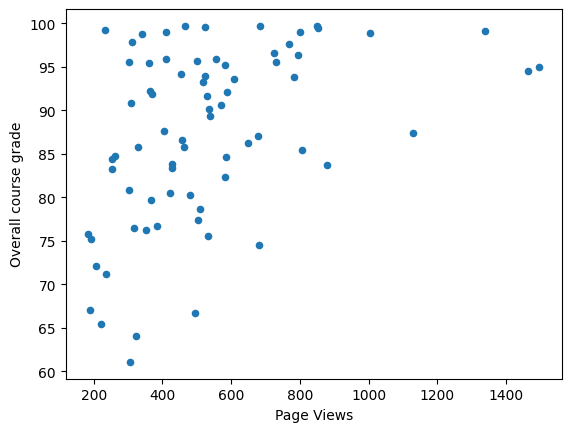

In [45]:
h = grades.plot.scatter("Page Views", "Overall course grade")

🧠 Whaddya think?  Is there a relationship between the number of page views and the student's grades 6 weeks into the course?

---

#### 4.3.3 - A few reductions

Let's play with reductions on the `grades` data frame.  

What's the average grade in the class?

In [46]:
np.mean(grades["Overall course grade"])

np.float64(87.30657184374891)

What's the max grade?  Who had it?

In [47]:
np.max(grades['Overall course grade'])

np.float64(99.68338381365511)

In [48]:
idx = grades['Overall course grade'].idxmax()
grades["Full name"][idx]

# or as a one-liner, 
grades["Full name"][grades['Overall course grade'].idxmax()]

'Grace Zhang'

🧠 Of all the students who have percent on-time no more than 80%, what was the maximum number of participations?  (Hint: use the `grades` data frame -- filter, then do a max on the `Participations` column)

In [ ]:
# your code here


In [61]:
# Filter students with on-time percent <= 80 and get max participations
max_participations = grades.loc[grades['Assignment on time percent'] <= 80, 'Participations'].max()
max_participations

np.int64(29)

### 4.4 - Conclusion

pandas is powerful and expressive.  Here are some additional things to practice, as time allows you:

🧠 Suggested student training exercises: 

* Which content did `s` view the most?  What was that content's type?
* Which content was viewed the most among all students?
* Which *page* was viewed the most?


---

## 5. Reading Text from a PDF

PDFs are one of the most common formats you'll encounter in professional and government data work. They're designed for human reading, not machine reading — which makes extracting structured information from them genuinely tricky. In this section we'll learn how to open a PDF, pull out raw text, understand what you actually get back, and use string operations and regular expressions to find structure in that text.

We'll use the first two pages of a real U.S. Bureau of Economic Analysis (BEA) GDP news release as our example document. This is the same report you'll work with in Assignment 6c, so this section is also a preview of what's waiting for you there.

### 5.1 — Installing and importing `pypdf`

`pypdf` is a pure-Python library for reading PDF files. If you haven't installed it yet, run this in your terminal (not in a notebook cell):

```
pip install pypdf
```

Once installed, import it like this:

In [49]:
import pypdf
import re
import pandas as pd

### 5.2 — Opening a PDF and extracting text

The main entry point in `pypdf` is `PdfReader`. You give it a filename, and it gives you an object that lets you access individual pages.

Pages are **zero-indexed**: page 1 of the document is `reader.pages[0]`.

Each page has an `extract_text()` method that returns a string.

In [50]:
reader = pypdf.PdfReader("gdp_report.pdf")
print(f"Number of pages: {len(reader.pages)}")

Number of pages: 9


In [51]:
# Extract text from page 1 (index 0)
page1_text = reader.pages[0].extract_text()
print(page1_text)

 
 
Page 1 of 9 
 
EMBARGOED UNTIL RELEASE AT 8:30 a.m. EDT, Thursday, April 9, 2026 BEA 26–19 
Technical: Lisa Mataloni (GDP) 301-278-9083 GDPNIWD@bea.gov 
 Kate Pinard (Corporate Profits) 
Todd Siebeneck (GDP by State) 
Matthew von Kerczek (State Income) 
301-278-9417 
301-278-9705 
301-278-9250 
CPNIWD@bea.gov 
GDPbyState@bea.gov 
REIS@bea.gov 
Media: Connie O’Connell 301-278-9003 Connie.OConnell@bea.gov 
 
GDP (Third Estimate), Industries, Corporate Profits, State GDP, 
and State Personal Income, 4th Quarter and Year 2025 
 
Real gross domestic product (GDP) increased at an annual rate of 0.5 percent in the fourth quarter of 
2025 (October, November, and December), according to the third estimate released today by the U.S. 
Bureau of Economic Analysis. In the third quarter of 2025, real GDP increased 4.4 percent. 
The third report for the fourth quarter of 2025, originally scheduled for March 27, 2026, was 
rescheduled due to the October–November 2025 government shutdown. 
 
Real G

### 5.3 — What you actually get back

Take a look at the output above. A few things to notice:

- The **narrative prose** extracts cleanly: complete sentences, correct punctuation, percent values intact.
- Toward the bottom you'll see something that looks like a jumble of numbers and labels — `-2.00`, `-1.00`, `Consumer spending`, `Advance`, `Second`, `Third`, and so on. That's not broken text; it's the **bar chart** that appears on page 1. PDF charts are drawn as vector graphics, and `pypdf` picks up their axis labels, tick values, and legend text as raw strings. This is completely normal and expected.

This is the fundamental challenge of PDF parsing: the useful text and the noise live side-by-side in the same string. Your job as a programmer is to find the signal.

Let's look at page 2 as well:

In [52]:
page2_text = reader.pages[1].extract_text()
print(page2_text)

 
Page 2 of 9 
 
GDP by industry 
From an industry perspective, the increase in real GDP reflected an increase of 2.3 percent in real value 
added for private services-producing industries that was partly offset by decreases of 7.8 percent in 
government and 1.8 percent in private goods-producing industries. The leading industry contributors to 
the increase in real GDP were wholesale trade, information, and health care and social assistance. 
 
Related economic measures 
Real final sales to private domestic purchasers, the sum of consumer spending and gross private fixed 
investment, increased 1.8 percent in the fourth quarter, revised down 0.1 percentage point from the 
previous estimate. 
 
Real gross output decreased 0.5 percent in the fourth quarter, reflecting decreases of 3.2 percent for 
private goods-producing industries and 4.7 percent for government that were partly offset by an 
increase of 1.1 percent for private services-producing industries. 
 
Real gross domestic income

Page 2 has a much larger chart (a waterfall chart of industry contributions), so there's considerably more noise after the narrative paragraphs. The pattern is the same though: clean prose up top, chart data below.

A practical habit: when working with a new PDF, always print the raw extraction first before writing any parsing code. What you see is what you have to work with.

### 5.4 — Concatenating pages

For most tasks you'll want the text from multiple pages joined into one string. A clean way to do this is with `join` over a list comprehension:

In [53]:
# Extract and concatenate the first two pages
raw_text = "\n".join(reader.pages[i].extract_text() for i in range(2))
print(f"Total characters extracted: {len(raw_text)}")

Total characters extracted: 4122


🧠 Modify the line above to extract **all 9 pages** instead of just the first two. How many characters does the full document produce?

In [54]:
# your code here
# Extract and concatenate all pages
raw_text = "\n".join(reader.pages[i].extract_text() for i in range(9))
print(f"Total characters extracted: {len(raw_text)}")

Total characters extracted: 14902


### 5.5 — Splitting text into sentences

Once you have raw text, a common first step is to split it into sentences so you can work with one idea at a time. A naive approach is to split on periods:

In [55]:
# Work with just the first page for now
sentences = page1_text.split(".")
for i, s in enumerate(sentences[:6]):
    print(f"[{i}] {s.strip()!r}")
    print()

[0] 'Page 1 of 9 \n \nEMBARGOED UNTIL RELEASE AT 8:30 a'

[1] 'm'

[2] 'EDT, Thursday, April 9, 2026 BEA 26–19 \nTechnical: Lisa Mataloni (GDP) 301-278-9083 GDPNIWD@bea'

[3] 'gov \n Kate Pinard (Corporate Profits) \nTodd Siebeneck (GDP by State) \nMatthew von Kerczek (State Income) \n301-278-9417 \n301-278-9705 \n301-278-9250 \nCPNIWD@bea'

[4] 'gov \nGDPbyState@bea'

[5] 'gov \nREIS@bea'



This gets us most of the way there, but splitting on `.` has well-known edge cases:

- Decimal numbers like `0.5` or `4.4` contain periods that are **not** sentence boundaries.
- Abbreviations like `U.S.` or `a.m.` also contain periods that are not sentence boundaries.

For the purposes of Assignment 6c, splitting on `.` and then filtering out fragments that are too short (or that consist entirely of numbers) is a reasonable pragmatic approach. You don't need a full natural language processing library — you just need something that works well enough on this document.

Here's a slightly more robust version that strips whitespace and drops very short fragments:

In [56]:
def split_sentences(text, min_length=20):
    """Split text on periods and return non-trivial fragments."""
    fragments = text.split(".")
    return [f.strip() for f in fragments if len(f.strip()) >= min_length]

sentences = split_sentences(page1_text)
print(f"Fragments found: {len(sentences)}")
for s in sentences[:5]:
    print(f"  → {s!r}")
    print()

Fragments found: 19
  → 'Page 1 of 9 \n \nEMBARGOED UNTIL RELEASE AT 8:30 a'

  → 'EDT, Thursday, April 9, 2026 BEA 26–19 \nTechnical: Lisa Mataloni (GDP) 301-278-9083 GDPNIWD@bea'

  → 'gov \n Kate Pinard (Corporate Profits) \nTodd Siebeneck (GDP by State) \nMatthew von Kerczek (State Income) \n301-278-9417 \n301-278-9705 \n301-278-9250 \nCPNIWD@bea'

  → 'gov \nMedia: Connie O’Connell 301-278-9003 Connie'

  → 'gov \n \nGDP (Third Estimate), Industries, Corporate Profits, State GDP, \nand State Personal Income, 4th Quarter and Year 2025 \n \nReal gross domestic product (GDP) increased at an annual rate of 0'



🧠 Look at the fragments printed above. Do any of them include chart noise rather than narrative text? How might you tell the difference programmatically — what makes a chart label look different from a sentence?

### 5.6 — Finding numbers with regular expressions

Once we have sentences, we often want to extract specific numeric values — for example, every percent value mentioned, or every dollar amount. This is where regular expressions become useful.

Recall that `re.findall(pattern, string)` returns a list of all non-overlapping matches of `pattern` in `string`.

#### Extracting percent values

A percent value in this document looks like a number (possibly with a decimal point) followed by the word `percent` or the symbol `%`. For example: `0.5 percent`, `4.4 percent`, `2.3 percent`.

The pattern `r"([\d.]+)\s*(?:percent|%)"` matches:
- `[\d.]+` — one or more digits or decimal points (the number)
- `\s*` — optional whitespace
- `(?:percent|%)` — the word "percent" or the symbol "%" (non-capturing group)

In [57]:
test_sentence = "Real GDP increased at an annual rate of 0.5 percent in the fourth quarter of 2025."

percent_pattern = r"([\d.]+)\s*(?:percent|%)"
matches = re.findall(percent_pattern, test_sentence)
print("Raw matches:", matches)

# Convert to floats
percent_values = [float(m) for m in matches]
print("As floats:", percent_values)

Raw matches: ['0.5']
As floats: [0.5]


Let's run this across all sentences from page 1 and see what we find:

In [58]:
for s in sentences:
    vals = [float(m) for m in re.findall(percent_pattern, s)]
    if vals:
        print(f"  {vals}  ←  {s[:80]!r}")

  [5.0]  ←  '5 percent in the fourth quarter of \n2025 (October, November, and December), acco'
  [2.0]  ←  '2 percentage point from the second estimate, primarily reflecting a \ndownward re'
  [5.0]  ←  '5 percent\nAdvance Second Third\nGDP Gross domestic product\nNote'


#### Extracting billion-dollar values

Dollar amounts followed by "billion" look like `$246.9 billion`. The `$` sign is optional (sometimes the text just says `246.9 billion`), so we use `\$?` to match it optionally.

The pattern `r"\$?([\d.]+)\s+billion"` matches:
- `\$?` — optional dollar sign
- `([\d.]+)` — the number (captured)
- `\s+billion` — whitespace then the word "billion"

In [59]:
billion_pattern = r"\$?([\d.]+)\s+billion"

# Test on a sentence we know contains a billion-dollar value
# (this sentence appears on page 3 of the full document)
test_sentence_b = "Profits from current production increased $246.9 billion in the fourth quarter."
matches_b = re.findall(billion_pattern, test_sentence_b)
print("Matches:", [float(m) for m in matches_b])

Matches: [246.9]


🧠 Pages 1–2 of the report don't contain billion-dollar values — those appear on page 3 onward. Using what you've just learned, write code that extracts all billion-dollar values from **page 3** of the PDF (`reader.pages[2]`). How many do you find, and what are they?

In [ ]:
# your code here


### 5.7 — Building a DataFrame from parsed text

Now let's put the pieces together. We'll loop over sentences from pages 1–2, and for each sentence record whether it mentions a percent value or not, and what those values are. This is the same structure you'll build for the full document in Assignment 6c.

The result is a DataFrame where each row is one sentence and the columns capture what we found in it.

In [60]:
rows = []

for sentence in split_sentences(raw_text):
    percent_vals = [float(m) for m in re.findall(percent_pattern, sentence)]
    row = {
        "sentence": sentence,
        "mentions_percent": len(percent_vals) > 0,
        "percent_values": percent_vals,
    }
    rows.append(row)

parsed_df = pd.DataFrame(rows)
print(f"Total sentences: {len(parsed_df)}")
print(f"Sentences mentioning percent: {parsed_df['mentions_percent'].sum()}")
parsed_df.head(8)

Total sentences: 154
Sentences mentioning percent: 47


,sentence,mentions_percent,percent_values
0,Page 1 of 9 \n \nEMBARGOED UNTIL RELEASE AT 8:...,False,[]
1,"EDT, Thursday, April 9, 2026 BEA 26–19 \nTechn...",False,[]
2,gov \n Kate Pinard (Corporate Profits) \nTodd ...,False,[]
3,gov \nMedia: Connie O’Connell 301-278-9003 Connie,False,[]
4,"gov \n \nGDP (Third Estimate), Industries, Cor...",False,[]
5,5 percent in the fourth quarter of \n2025 (Oct...,True,[5.0]
6,Bureau of Economic Analysis,False,[]
7,"In the third quarter of 2025, real GDP increas...",False,[]


🧠 Filter `parsed_df` to show only the rows where `mentions_percent` is `True`. Do all of the matching sentences look like genuine narrative text, or do some appear to be chart noise? What characteristic of the sentence text helps you tell the difference?

In [ ]:
# your code here


### 5.8 — Saving to CSV

One subtlety when saving DataFrames that contain lists as cell values: `to_csv` will convert each list to its string representation, which is readable but not directly parseable as a list on re-import. For this course, that's fine — we just want a human-readable record.

Two things to note about the call below:
- `index=False` skips the integer row index (you've seen this before)
- `na_rep=''` writes missing values as empty strings rather than `NaN`

In [ ]:
parsed_df.to_csv("gdp_preview.csv", index=False, na_rep='')
print("Saved gdp_preview.csv")

🧠 Open `gdp_preview.csv` in your IDE and look at the `percent_values` column. What does a list like `[0.5, 4.4]` look like when stored as CSV text? What would you need to do to recover a Python list from that string if you re-loaded the CSV with pandas?

---

### 5.9 — Summary

Here's the pattern you've just practiced — it generalizes to almost any PDF parsing task:

1. **Open** the PDF with `pypdf.PdfReader`
2. **Extract** text page by page with `.extract_text()`
3. **Concatenate** pages into one string with `join`
4. **Inspect** the raw output before writing any parsing code — understand the noise
5. **Split** the text into meaningful units (sentences, lines, sections)
6. **Extract** values of interest using `re.findall`
7. **Build** a DataFrame row by row
8. **Save** with `to_csv`

In Assignment 6c you'll apply this same pattern to all 9 pages of the GDP report, with additional structure: tracking which section each sentence belongs to, handling a compact data table, and packaging everything into reusable functions.

---

After completing the guided practice above, log onto Canvas to complete Quiz 6c. You may wish to keep this notebook open while you work.